In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import sys

sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses')
sys.path.append('//allen/aics/assay-dev/users/Erin/git-repos/cellsmap/cellsmap/analyses/utils/sparse_vfc')

# sparse VFC alg code and phase plane analysis code
import sparseVFC as svfc
import utils.pplane as pplane

# Euler-Maruyama for stochastic simulation of trajectories
from utils.stochastic_sim import stochastic_sim_EM

from sklearn.model_selection import train_test_split

## Load MAE data

Masked autoencoder dataset info:
- columns 0-255 are the latent features of the contrastive model
- location gives a unique id for each 512x512 patch of the image (stitched FOVs) that is consistent across time (54 locations)
- time is the index into the movie (0 to 576, units 5 minutes)

Original endothelial cell dataset info (from `cellsmap/cellsmap/data_config.yaml`):
- flow rate of 20 dyn/cm^2 from 0 to 24 hours
- flow rate of 6 dyn/cm^2 from 24 to 48 hours
- time interval between images (data points) is 5 minutes

Data loaded and preprocessed in `mae_feats_init.py`.

In [4]:
exp_var = np.load('../data/MAE_ExpVar.npy')
pcs = np.load('../data/MAE_PCs.npy')

num_modes_95 = np.where(np.cumsum(exp_var) > 0.95)[0].min()
print("Number of modes to explain 95% of variance: ", num_modes_95)

Number of modes to explain 95% of variance:  12


In [5]:
X_t = np.load('../data/MAE_95pctVarPCs_all.npy') # preprocessed data: num_loc * num_timepoints * num_modes_95 array

X_t_high = np.load('../data/MAE_95pctVarPCs_highFlow.npy')
X_t_low = np.load('../data/MAE_95pctVarPCs_lowFlow.npy')

num_loc = X_t.shape[0]
num_t = X_t.shape[1]
t_change = (24*60 - 25)//5 # time point (frame number) at which to change from high to low flow occurs (25 minutes before 24 hours)

Text(0, 0.5, 'PC1')

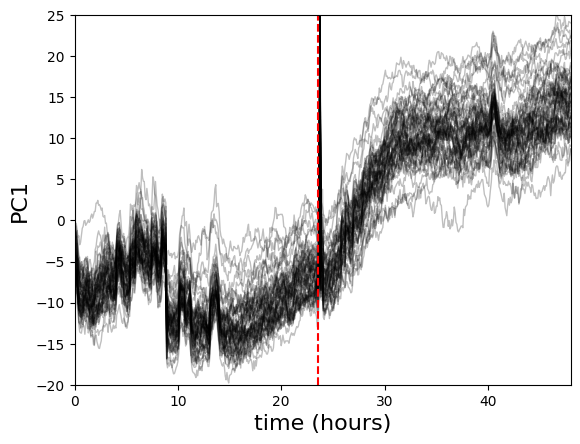

In [6]:
# plot top PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,0],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-20,25])
plt.vlines(5*t_change/60,-20,25,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC1", fontsize=16)

Text(0, 0.5, 'PC2')

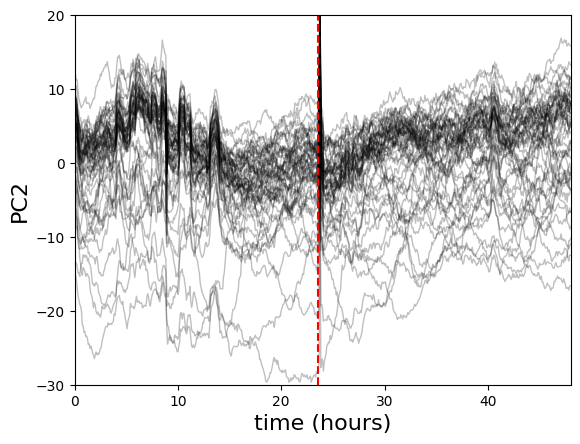

In [7]:
# plot 2nd PCA mode vs time for each location at high flow
for i in range(num_loc):
    plt.plot(5*np.arange(num_t)/60,X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
plt.xlim([0,(num_t)*5//60])
plt.ylim([-30,20])
plt.vlines(5*t_change/60,-30,20,color='r',linestyles='dashed')
#plt.vlines(530/60,-20,25,color='b',linestyles='dashed')
plt.xlabel("time (hours)", fontsize=16)
plt.ylabel("PC2", fontsize=16)

Text(0, 0.5, 'PC2')

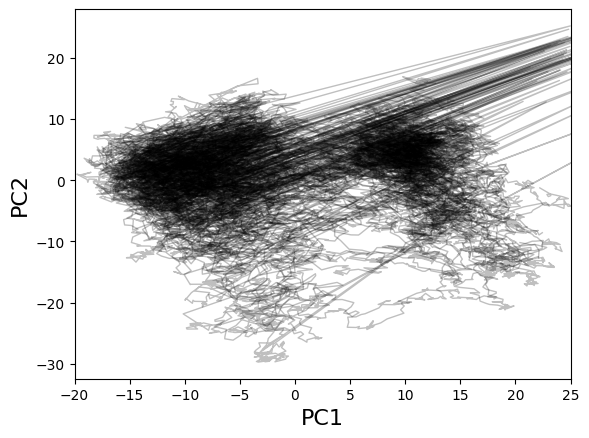

In [8]:
for i in range(num_loc):
    plt.plot(X_t[i,:,0],X_t[i,:,1],'k-',alpha=0.25,linewidth=1)
#plt.xlim([0,(num_t)*5])
plt.xlim([-20,25])
plt.xlabel("PC1", fontsize=16)
plt.ylabel("PC2", fontsize=16)

## SparseVFC vector field learning

In [ ]:
dt = 5 # time units = (5 minutes)/dt 

# get drift (linear variation) and diffusion (quadratic variation) vectors for each trajectory
dX_high = (X_t_high[:,1:,:] - X_t_high[:,:-1,:])/dt
dX2_high = dt*(dX_high)**2 # assuming diffusion matrix is diagonal, for simplicity
dX_low = (X_t_low[:,6:,:] - X_t_low[:,5:-1,:])/dt
dX2_low = dt*(dX_low)**2

In [ ]:
# now, build arrays of X (points along single cell trajectories) and corresponding Y = dX/dt|_X: dim is (num_traj*num_t) x num_feats
X_high = np.concatenate(X_t_high[:,:-1,:],axis=0)
Y_high = np.concatenate(dX_high,axis=0) # drift vectors
V_high = np.concatenate(dX2_high,axis=0) # diffusion vectors
X_low = np.concatenate(X_t_low[:,5:-1,:],axis=0)
Y_low = np.concatenate(dX_low,axis=0)
V_low = np.concatenate(dX2_low,axis=0)

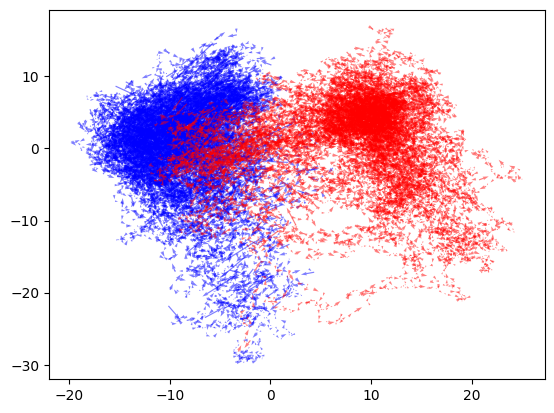

In [ ]:
plt.quiver(X_high[:,0],X_high[:,1],Y_high[:,0],Y_high[:,1],color='b',alpha=0.5,scale=20) # plot high flow veolcity vectors in top two PCA space
plt.quiver(X_low[:,0],X_low[:,1],Y_low[:,0],Y_low[:,1],color='r',alpha=0.5,scale=20) # plot low flow veolcity vectors in top two PCA space

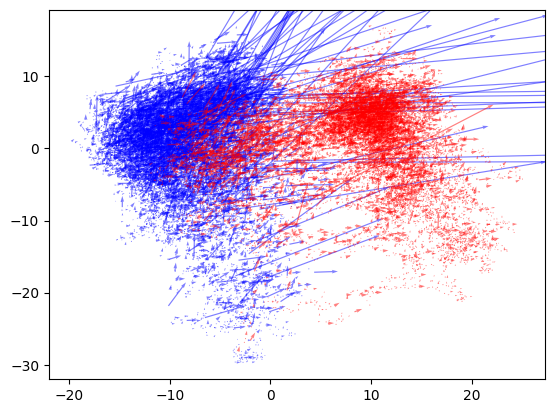

In [ ]:
plt.quiver(X_high[:,0],X_high[:,1],V_high[:,0],V_high[:,1],color='b',alpha=0.5,scale=30) # plot high flow veolcity vectors in top two PCA space
plt.quiver(X_low[:,0],X_low[:,1],V_low[:,0],V_low[:,1],color='r',alpha=0.5,scale=30) # plot low flow veolcity vectors in top two PCA space

### Binning state space

In [ ]:
# bin state space

N = 32
min0 = X_high[:,0].min()
max0 = X_high[:,0].max()
bin0_min = 0.5*(np.floor(min0)+np.round(min0,1))
bin0_max = 0.5*(np.ceil(max0)+np.round(max0,1))
bins0 = np.linspace(bin0_min, bin0_max, N+1)
centers0 = 0.5*(bins0[1:]+bins0[:-1])


min1 = X_high[:,1].min()
max1 = X_high[:,1].max()
bin1_min = 0.5*(np.floor(min1)+np.round(min1,1))
bin1_max = 0.5*(np.ceil(max1)+np.round(max1,1))
bins1 = np.linspace(bin1_min, bin1_max, N+1)
centers1 = 0.5*(bins1[1:]+bins1[:-1])

dx_high = [bins0[1]-bins0[0],bins1[1]-bins1[0]]


bins_high = [bins0,bins1]
centers_high = [centers0,centers1]

In [ ]:
f_KM_high = np.nan*np.ones((len(bins_high[0])-1,len(bins_high[1])-1,2))
a_KM_high = np.nan*np.ones(f_KM_high.shape)
f_err_high = np.nan*np.ones(f_KM_high.shape)
a_err_high = np.nan*np.ones(f_KM_high.shape)

id1 = np.digitize(X_high[:,0],bins_high[0]) # which dimension 1 bin
id2 = np.digitize(X_high[:,1],bins_high[1]) # which dimension 2 bin
uids = list(set(zip(id1,id2))) # unique bin ids

for uid in uids:
    mask = np.where((id1==uid[0])*(id2==uid[1]))[0]
    # At each histogram bin, find time series points where the state falls into this bin
    f_KM_high[uid[0]-1,uid[1]-1,:] = np.mean(Y_high[mask,:2],axis=0) # Conditional average  ~ drift
    a_KM_high[uid[0]-1,uid[1]-1,:] = 0.5*np.mean(V_high[mask,:2],axis=0) # Conditional variance  ~ diffusion

    # Estimate error by variance of samples in the bin
    f_err_high[uid[0]-1,uid[1]-1,:] = np.std(Y_high[mask,:2],axis=0)/np.sqrt(len(mask))
    a_err_high[uid[0]-1,uid[1]-1,:] = np.std(V_high[mask,:2],axis=0)/np.sqrt(len(mask))

In [ ]:
# bin state space

N = 32
min0 = X_low[:,0].min()
max0 = X_low[:,0].max()
bin0_min = 0.5*(np.floor(min0)+np.round(min0,1))
bin0_max = 0.5*(np.ceil(max0)+np.round(max0,1))
bins0 = np.linspace(bin0_min, bin0_max, N+1)
centers0 = 0.5*(bins0[1:]+bins0[:-1])


min1 = X_low[:,1].min()
max1 = X_low[:,1].max()
bin1_min = 0.5*(np.floor(min1)+np.round(min1,1))
bin1_max = 0.5*(np.ceil(max1)+np.round(max1,1))
bins1 = np.linspace(bin1_min, bin1_max, N+1)
centers1 = 0.5*(bins1[1:]+bins1[:-1])

dx_low = [bins0[1]-bins0[0],bins1[1]-bins1[0]]


bins_low = [bins0,bins1]
centers_low = [centers0,centers1]

In [ ]:
f_KM_low = np.nan*np.ones((len(bins_low[0])-1,len(bins_low[1])-1,2))
a_KM_low = np.nan*np.ones(f_KM_low.shape)
f_err_low = np.nan*np.ones(f_KM_low.shape)
a_err_low = np.nan*np.ones(f_KM_low.shape)

id1 = np.digitize(X_low[:,0],bins_low[0]) # which dimension 1 bin
id2 = np.digitize(X_low[:,1],bins_low[1]) # which dimension 2 bin
uids = list(set(zip(id1,id2))) # unique bin ids

for uid in uids:
    mask = np.where((id1==uid[0])*(id2==uid[1]))[0]
    # At each histogram bin, find time series points where the state falls into this bin
    f_KM_low[uid[0]-1,uid[1]-1,:] = np.mean(Y_low[mask,:2],axis=0) # Conditional average  ~ drift
    a_KM_low[uid[0]-1,uid[1]-1,:] = 0.5*np.mean(V_low[mask,:2],axis=0) # Conditional variance  ~ diffusion

    # Estimate error by variance of samples in the bin
    f_err_low[uid[0]-1,uid[1]-1,:] = np.std(Y_low[mask,:2],axis=0)/np.sqrt(len(mask))
    a_err_low[uid[0]-1,uid[1]-1,:] = np.std(V_low[mask,:2],axis=0)/np.sqrt(len(mask))

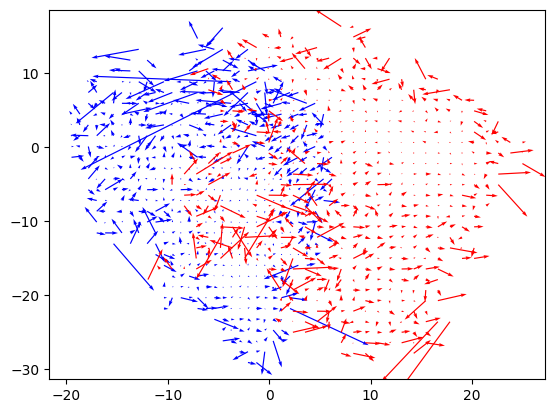

In [ ]:
plt.quiver(centers_high[0],centers_high[1],f_KM_high[:,:,0],f_KM_high[:,:,1],color='b') # plot high flow veolcity vectors in top two PCA space
plt.quiver(centers_low[0],centers_low[1],f_KM_low[:,:,0],f_KM_low[:,:,1],color='r') # plot low flow veolcity vectors in top two PCA space

In [ ]:
c1,c2 = np.meshgrid(centers_high[0],centers_high[1])
X_mesh_high = np.zeros((N,N,2))
for i in range(N):
    for j in range(N):
        X_mesh_high[i,j,0] = c1[i,j]
        X_mesh_high[i,j,1] = c2[i,j]
mask_high = np.where(np.isfinite(f_KM_high))
X_pts_high = X_mesh_high[mask_high[0],mask_high[1]].reshape((-1,2))

In [ ]:
c1,c2 = np.meshgrid(centers_low[0],centers_low[1])
X_mesh_low = np.zeros((N,N,2)) 
for i in range(N):
    for j in range(N):
        X_mesh_low[i,j,0] = c1[i,j]
        X_mesh_low[i,j,1] = c2[i,j]
mask_low = np.where(np.isfinite(f_KM_low))
X_pts_low = X_mesh_low[mask_low[0],mask_low[1]].reshape((-1,2))

In [ ]:
# build training and test sets
N_tot_high = X_pts_high.shape[0]
N_train_high=int(0.8*N_tot_high) # 80% of data for training
N_test_high = N_tot_high-N_train_high

X_train_high, X_test_high, Y_train_high, Y_test_high = train_test_split(X_pts_high, f_KM_high[mask_high[0],mask_high[1]], test_size=N_test_high, random_state=342)
_, _, V_train_high, V_test_high = train_test_split(X_pts_high, a_KM_high[mask_high[0],mask_high[1]], test_size=N_test_high, random_state=342) # same random seed to get same x points for train and test

# build training and test sets
N_tot_low = X_pts_low.shape[0]
N_train_low=int(0.8*N_tot_low) # 80% of data for training
N_test_low = N_tot_low-N_train_low

X_train_low, X_test_low, Y_train_low, Y_test_low = train_test_split(X_pts_low, f_KM_low[mask_low[0],mask_low[1]], test_size=N_test_low, random_state=2349)
_, _, V_train_low, V_test_low = train_test_split(X_pts_low, a_KM_low[mask_low[0],mask_low[1]], test_size=N_test_low, random_state=2349) # same random seed to get same x points for train and test

#### High flow

In [ ]:
drift_high = svfc.SparseVFC(kernel='rbf',beta=0.01,M=500,seed=25).fit(X_train_high,Y_train_high)

drift_inliers = drift_high.inliers_

drift_R2 = drift_high.score(X_test_high,Y_test_high)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(drift_inliers) == 0:
    drift_inliers_err = np.nan
else:
    drift_inliers_err = np.sqrt((1/len(drift_inliers))*np.sum(np.linalg.norm(drift_high.predict(X_train_high[drift_inliers,:])-Y_train_high[drift_inliers,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(drift_inliers))
print('Coefficient of determination (R^2) of drift (RBF kernel) model on test set: %f' %drift_R2)
print('Standard deviation of drift (RBF kernel) model on training set inliers: %f' %drift_inliers_err)

Number of inlier points identified by SparseVFC algorithm:  904
Coefficient of determination (R^2) of drift (RBF kernel) model on test set: 0.028473
Standard deviation of drift (RBF kernel) model on training set inliers: 0.082549


In [ ]:
diff_high = svfc.SparseVFC(kernel='rbf',beta=0.01,M=500,seed=25).fit(X_train_high,V_train_high)

diff_inliers = diff_high.inliers_

diff_R2 = diff_high.score(X_test_high,V_test_high)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(diff_inliers) == 0:
    diff_inliers_err = np.nan
else:
    diff_inliers_err = np.sqrt((1/len(diff_inliers))*np.sum(np.linalg.norm(diff_high.predict(X_train_high[diff_inliers,:])-V_train_high[diff_inliers,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(diff_inliers))
print('Coefficient of determination (R^2) of diffusion (RBF kernel) model on test set: %f' %diff_R2)
print('Standard deviation of diffusion (RBF kernel) model on training set inliers: %f' %diff_inliers_err)

Number of inlier points identified by SparseVFC algorithm:  827
Coefficient of determination (R^2) of diffusion (RBF kernel) model on test set: -0.010091
Standard deviation of diffusion (RBF kernel) model on training set inliers: 0.038801


In [ ]:
W = np.eye(2)
drift_high.project2D(W) # projects coefficent vectors into 2D (each coefficient vector is a row vector)
diff_high.project2D(W)

In [ ]:
xlim = [-24,24]
ylim = [-24,24]
N_mesh=40
bins = [np.linspace(xlim[0],xlim[1],N_mesh+1),np.linspace(ylim[0],ylim[1],N_mesh+1)]
centers = [0.5*(bins[0][1:]+bins[0][:-1]),0.5*(bins[1][1:]+bins[1][:-1])]
dx = [bins[0][1]-bins[0][0],bins[1][1]-bins[1][0]]
X1,X2 = np.meshgrid(centers[0],centers[1])
F_high = drift_high.predict_2D_mesh([X1,X2])
A_high = diff_high.predict_2D_mesh([X1,X2])

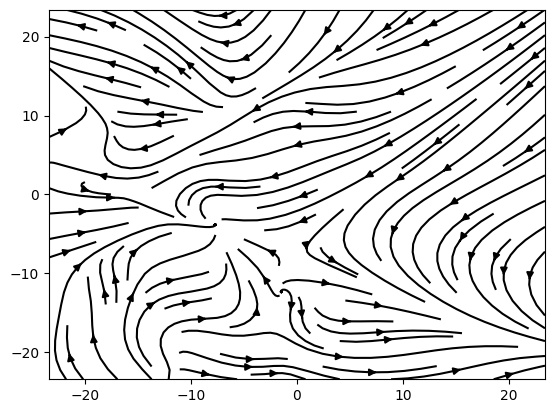

In [ ]:
plt.streamplot(X1,X2,F_high[:,:,0],F_high[:,:,1],color='k')

In [ ]:
def svfc_eval(X1,X2,svfc_2D):
    if not hasattr(svfc_2D,'proj_'): 
        svfc_2D.project2D(np.eye(2))
    if X1.ndim == 2:
        return np.swapaxes(svfc_2D.predict_2D_mesh([X1,X2]),0,1).T
    else:
        return svfc_2D.predict_2D(np.array([X1,X2]))[0]

def f_high(x):
        return svfc_eval(x[0],x[1],drift_high)

def f1_high(x1,x2):
    return f_high([x1,x2])[0]

def f2_high(x1,x2):
    return f_high([x1,x2])[1]


def a_high(x):
        return svfc_eval(x[0],x[1],diff_high)

def a1_high(x1,x2):
    return a_high([x1,x2])[0]

def a2_high(x1,x2):
    return a_high([x1,x2])[1]

Fixed points:
  • Saddle point at x = (-23.711,4.338)
  • Stable node at x = (-35.894,28.329)
  • Saddle point at x = (-0.504,-7.553)
  • Stable spiral at x = (-7.686,-3.853)
  • Saddle point at x = (-2.306,-14.724)
  • Unstable spiral at x = (-1.486,-12.253)


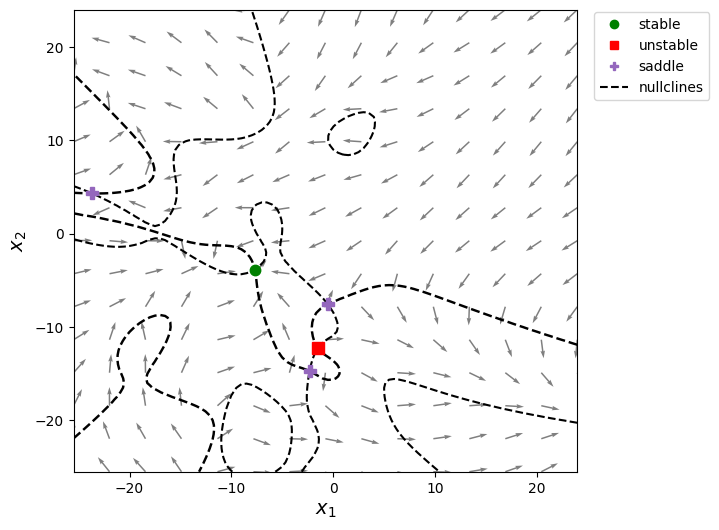

In [ ]:
x1 = np.linspace(xlim[0]-1.5,xlim[1],100)
x2 = np.linspace(ylim[0]-1.5,ylim[1],100)
fig = pplane.plot_portrait(f1_high,f2_high,x1,x2)

Text(0, 0.5, '$x_2$')

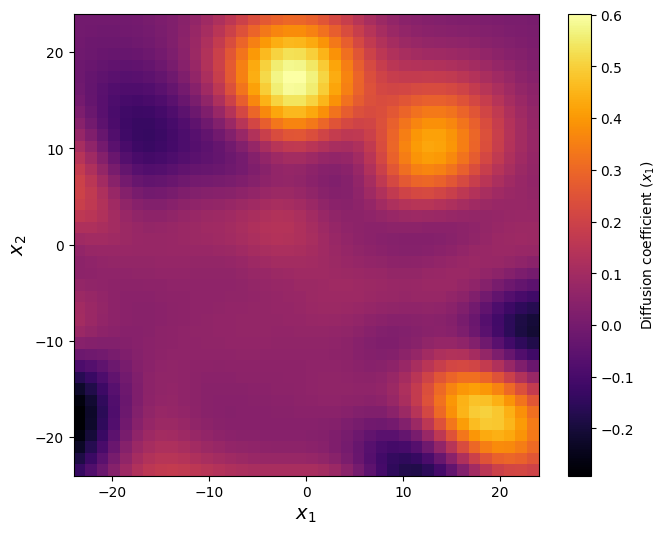

In [ ]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,A_high[:,:,0].T,cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_1$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Text(0, 0.5, '$x_2$')

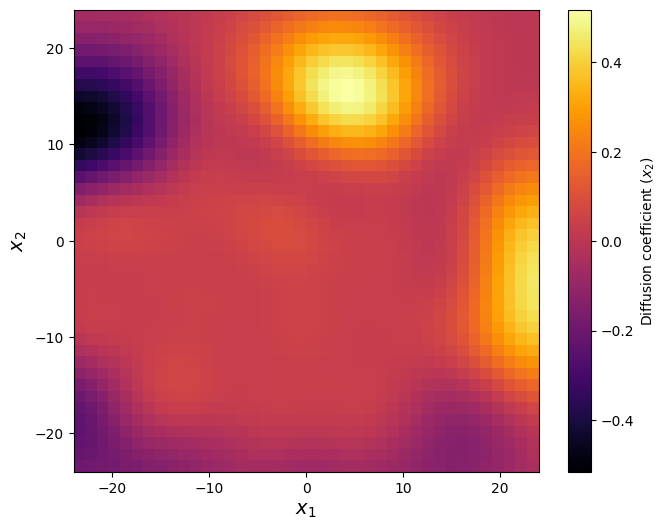

In [ ]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,A_high[:,:,1].T,cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_2$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
p_hist = np.histogram2d(X_t_high[:,100:,0].flatten(),X_t_high[:,100:,1].flatten(),bins=bins,density=True)[0]
fp = fps.SteadyFP((N_mesh,N_mesh), dx)
p_fit = fp.solve(F_high.T,A_high.T)
print('KL divergence (sparseVFC model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

KL divergence (sparseVFC model): 2.81842


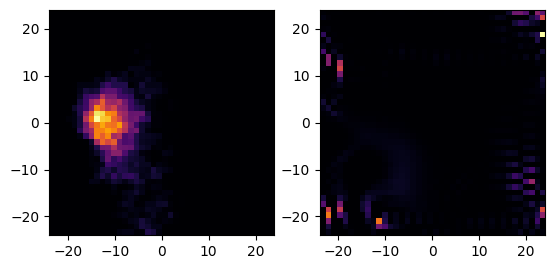

In [ ]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_fit.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20) # simulate 20 random trajectories with starting points from high flow data
inits = X_t_high[inits_idx,0,:2]

traj_model = stochastic_sim_EM(inits, f_high, lambda x: np.sqrt(2*a_high(x)), t_change, dt)

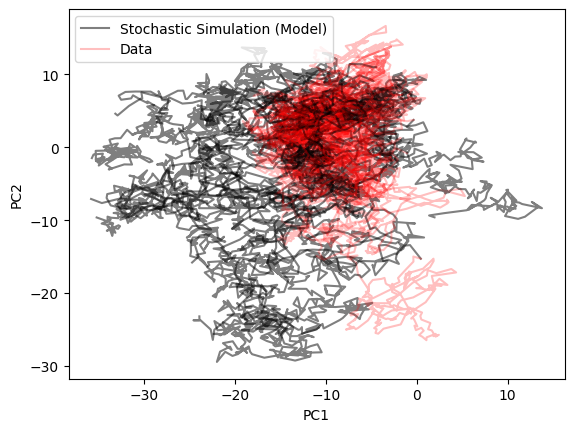

In [ ]:
for i in range(len(inits)):
    my_idx = np.where((abs(traj_model[i,:,0]) < 35)*(abs(traj_model[i,:,1]) < 35))[0]
    if len(my_idx) == 0:
        my_idx = traj_model[i,:,0].shape[0]
    else:
        my_idx = my_idx[-1]
    plt.plot(traj_model[i,:my_idx,0],traj_model[i,:my_idx,1],'k-',alpha=0.5)
    plt.plot(X_t_high[inits_idx[i],:,0],X_t_high[inits_idx[i],:,1],'r-',alpha=0.25)

#plt.ylim([-20,25])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(['Stochastic Simulation (Model)','Data'])

#### Low flow

In [ ]:
drift_low = svfc.SparseVFC(kernel='rbf',beta=0.01,M=500,seed=35).fit(X_train_low,Y_train_low)

drift_inliers = drift_low.inliers_

drift_R2 = drift_low.score(X_test_low,Y_test_low)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(drift_inliers) == 0:
    drift_inliers_err = np.nan
else:
    drift_inliers_err = np.sqrt((1/len(drift_inliers))*np.sum(np.linalg.norm(drift_low.predict(X_train_low[drift_inliers,:])-Y_train_low[drift_inliers,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(drift_inliers))
print('Coefficient of determination (R^2) of drift (RBF kernel) model on test set: %f' %drift_R2)
print('Standard deviation of drift (RBF kernel) model on training set inliers: %f' %drift_inliers_err)

Number of inlier points identified by SparseVFC algorithm:  866
Coefficient of determination (R^2) of drift (RBF kernel) model on test set: 0.119909
Standard deviation of drift (RBF kernel) model on training set inliers: 0.062536


In [ ]:
diff_low = svfc.SparseVFC(kernel='rbf',beta=0.01,M=500,seed=35).fit(X_train_low,V_train_low)

diff_inliers = diff_low.inliers_

diff_R2 = diff_low.score(X_test_low,V_test_low)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(diff_inliers) == 0:
    diff_inliers_err = np.nan
else:
    diff_inliers_err = np.sqrt((1/len(diff_inliers))*np.sum(np.linalg.norm(diff_low.predict(X_train_low[diff_inliers,:])-V_train_low[diff_inliers,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(diff_inliers))
print('Coefficient of determination (R^2) of diffusion (RBF kernel) model on test set: %f' %diff_R2)
print('Standard deviation of diffusion (RBF kernel) model on training set inliers: %f' %diff_inliers_err)

Number of inlier points identified by SparseVFC algorithm:  870
Coefficient of determination (R^2) of diffusion (RBF kernel) model on test set: -0.002232
Standard deviation of diffusion (RBF kernel) model on training set inliers: 0.026918


In [ ]:
W = np.eye(2)
drift_low.project2D(W) # projects coefficent vectors into 2D (each coefficient vector is a row vector)
diff_low.project2D(W)

In [ ]:
xlim = [-24,24]
ylim = [-24,24]
N_mesh=40
bins = [np.linspace(xlim[0],xlim[1],N_mesh+1),np.linspace(ylim[0],ylim[1],N_mesh+1)]
centers = [0.5*(bins[0][1:]+bins[0][:-1]),0.5*(bins[1][1:]+bins[1][:-1])]
dx = [bins[0][1]-bins[0][0],bins[1][1]-bins[1][0]]
X1,X2 = np.meshgrid(centers[0],centers[1])
F_low = drift_low.predict_2D_mesh([X1,X2])
A_low = diff_low.predict_2D_mesh([X1,X2])

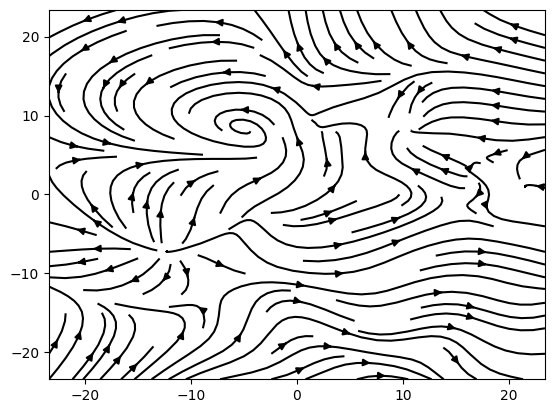

In [ ]:
plt.streamplot(X1,X2,F_low[:,:,0],F_low[:,:,1],color='k')

In [ ]:
def svfc_eval(X1,X2,svfc_2D):
    if not hasattr(svfc_2D,'proj_'): 
        svfc_2D.project2D(np.eye(2))
    if X1.ndim == 2:
        return np.swapaxes(svfc_2D.predict_2D_mesh([X1,X2]),0,1).T
    else:
        return svfc_2D.predict_2D(np.array([X1,X2]))[0]

def f_low(x):
        return svfc_eval(x[0],x[1],drift_low)

def f1_low(x1,x2):
    return f_low([x1,x2])[0]

def f2_low(x1,x2):
    return f_low([x1,x2])[1]


def a_low(x):
        return svfc_eval(x[0],x[1],diff_low)

def a1_high(x1,x2):
    return a_low([x1,x2])[0]

def a2_high(x1,x2):
    return a_low([x1,x2])[1]

Fixed points:
  • Saddle point at x = (-28.014,4.523)
  • Saddle point at x = (-8.612,-12.796)
  • Unstable node at x = (-12.366,-7.259)
  • Saddle point at x = (15.694,-1.359)
  • Stable spiral at x = (-5.086,8.314)
  • Saddle point at x = (8.180,9.161)
  • Stable spiral at x = (10.925,7.996)
  • Unstable node at x = (16.241,2.976)
  • Saddle point at x = (17.565,4.764)
  • Stable spiral at x = (21.480,1.102)


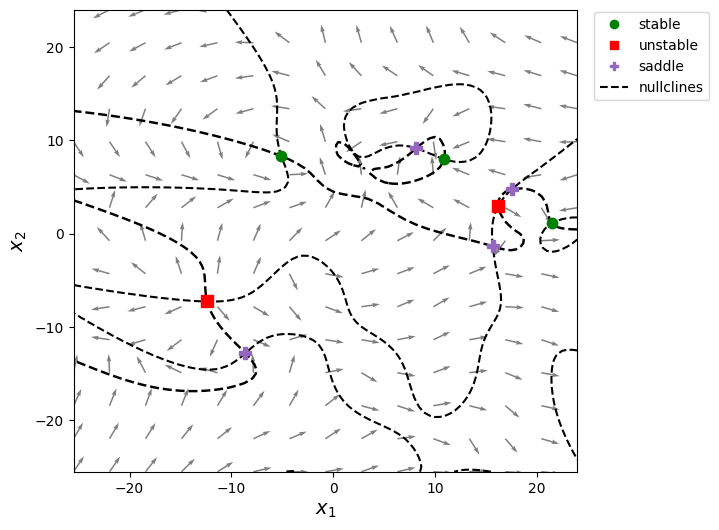

In [ ]:
x1 = np.linspace(xlim[0]-1.5,xlim[1],100)
x2 = np.linspace(ylim[0]-1.5,ylim[1],100)
fig = pplane.plot_portrait(f1_low,f2_low,x1,x2)

Text(0, 0.5, '$x_2$')

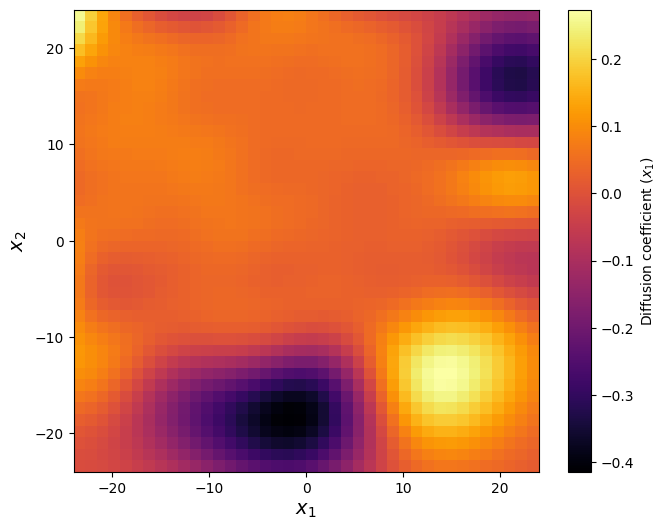

In [ ]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,A_low[:,:,0].T,cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_1$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

Text(0, 0.5, '$x_2$')

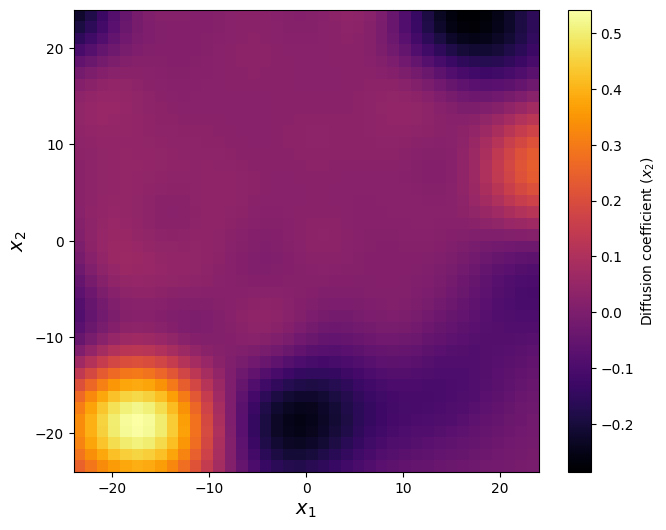

In [ ]:
fig = plt.figure(figsize=(7.5,6))
ax = plt.gca()
im = ax.pcolormesh(X1,X2,A_low[:,:,1].T,cmap='inferno')
fig.colorbar(im, ax=ax, label='Diffusion coefficient ($x_2$)')
plt.xlabel("$x_1$",fontsize=14)
plt.ylabel("$x_2$", fontsize=14)

In [ ]:
# Compare PDFs: empirical vs Fokker-Planck solution with model
p_hist = np.histogram2d(X_t_low[:,50:,0].flatten(),X_t_low[:,50:,1].flatten(),bins=bins,density=True)[0]
fp = fps.SteadyFP((N_mesh,N_mesh), dx)
p_fit = fp.solve(F_low.T,A_low.T)
print('KL divergence (sparseVFC model): {0:0.5f}'.format(tc.kl_divergence(p_hist, p_fit, dx=dx, tol=1e-6)))

KL divergence (sparseVFC model): 1.70370


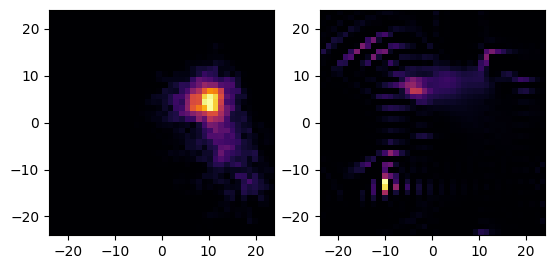

In [ ]:
# PDF of states
fig,ax = plt.subplots(1,2)
ax[0].imshow(p_hist.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]))

ax[1].imshow(p_fit.T,interpolation='nearest', origin='lower',
           extent=[bins[0][0], bins[0][-1], bins[1][0], bins[1][-1]],
           cmap='inferno', aspect=(bins[0][-1]-bins[0][0])/(bins[1][-1]-bins[1][0]),vmin=0)

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = X_t_low[inits_idx,5,:2]

traj_model = stochastic_sim_EM(inits, f_low, lambda x: np.sqrt(2*a_low(x)), num_t - t_change - 5, dt)

/tmp/ipykernel_4685/321415188.py:4: RuntimeWarning: invalid value encountered in sqrt
  traj_model = stochastic_sim_EM(inits, f_low, lambda x: np.sqrt(2*a_low(x)), num_t - t_change - 5, dt)


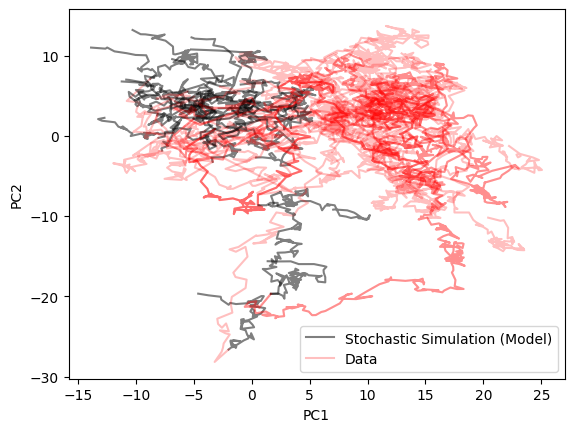

In [ ]:
for i in range(len(inits)):
    my_idx = np.where((abs(traj_model[i,:,0]) < 35)*(abs(traj_model[i,:,1]) < 35))[0]
    if len(my_idx) == 0:
        my_idx = traj_model[i,:,0].shape[0]
    else:
        my_idx = my_idx[-1]
    plt.plot(traj_model[i,:my_idx,0],traj_model[i,:my_idx,1],'k-',alpha=0.5)
    plt.plot(X_t_low[inits_idx[i],5:,0],X_t_low[inits_idx[i],5:,1],'r-',alpha=0.25)

#plt.ylim([-20,25])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(['Stochastic Simulation (Model)','Data'])

(Try simulation with manual model switch at flow change time)

### Full dataset (no binning)

In [ ]:
# build training and test sets
N_tot_high = X_high.shape[0]
N_train_high=int(0.8*N_tot_high) # 80% of data for training
N_test_high = N_tot_high-N_train_high

X_train_high, X_test_high, Y_train_high, Y_test_high = train_test_split(X_high, Y_high, test_size=N_test_high, random_state=342)

# build training and test sets
N_tot_low = X_low.shape[0]
N_train_low=int(0.8*N_tot_low) # 80% of data for training
N_test_low = N_tot_low-N_train_low

X_train_low, X_test_low, Y_train_low, Y_test_low = train_test_split(X_low, Y_low, test_size=N_test_low, random_state=2349)

##### Model training: high flow

In [ ]:
svfc_model_high = svfc.SparseVFC(kernel='rbf',beta=0.05,M=250,seed=25).fit(X_train_high,Y_train_high)

inlier_idx = svfc_model_high.inliers_

R2_rbf_test = svfc_model_high.score(X_test_high,Y_test_high)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(inlier_idx) == 0:
    stdev_rbf_inliers = np.nan
else:
    stdev_rbf_inliers = np.sqrt((1/len(inlier_idx))*np.sum(np.linalg.norm(svfc_model_high.predict(X_train_high[inlier_idx,:])-Y_train_high[inlier_idx,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(inlier_idx))
print('Coefficient of determination (R^2) of RBF kernel model on test set: %f' %R2_rbf_test)
print('Standard deviation of RBF kernel model on training set inliers: %f' %stdev_rbf_inliers)

Number of inlier points identified by SparseVFC algorithm:  11592
Coefficient of determination (R^2) of RBF kernel model on test set: -0.002570
Standard deviation of RBF kernel model on training set inliers: 0.375388


In [ ]:
# data already along PC components
# so projection matrix to top 2 pc components is just the (num_modes_95)x2 matrix [e_0 e_1]
W = np.column_stack((np.eye(num_modes_95)[0,:],np.eye(num_modes_95)[1,:]))
svfc_model_high.project2D(W) # projects coefficent vectors into 2D (each coefficient vector is a row vector)

In [ ]:
xlim = [-20,30]
ylim = [-20,30]
N_mesh = 40
U1,U2 = np.meshgrid(np.linspace(xlim[0],xlim[1],N_mesh),np.linspace(ylim[0],ylim[1],N_mesh))
V = svfc_model_high.predict_2D_mesh([U1,U2])

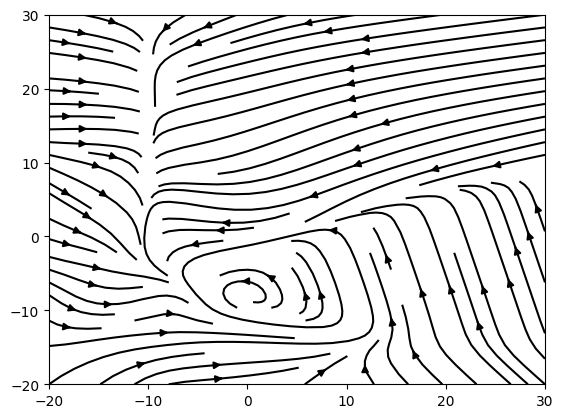

In [ ]:
fig = plt.streamplot(U1,U2,V[:,:,0],V[:,:,1],color='k')

In [ ]:
def f(X1,X2,svfc_2D):
    if not hasattr(svfc_2D,'proj_'): 
        svfc_2D.project2D(np.eye(2))
    if X1.ndim == 2:
        return np.swapaxes(svfc_2D.predict_2D_mesh([X1,X2]),0,1).T
    else:
        return svfc_2D.predict_2D(np.array([X1,X2]))[0]

def f1(x1,x2):
    return f(x1,x2,svfc_model_high)[0]

def f2(x1,x2):
    return f(x1,x2,svfc_model_high)[1]

Fixed points:
  • Unstable node at x = (-27.144,14.319)
  • Unstable spiral at x = (0.151,-8.034)


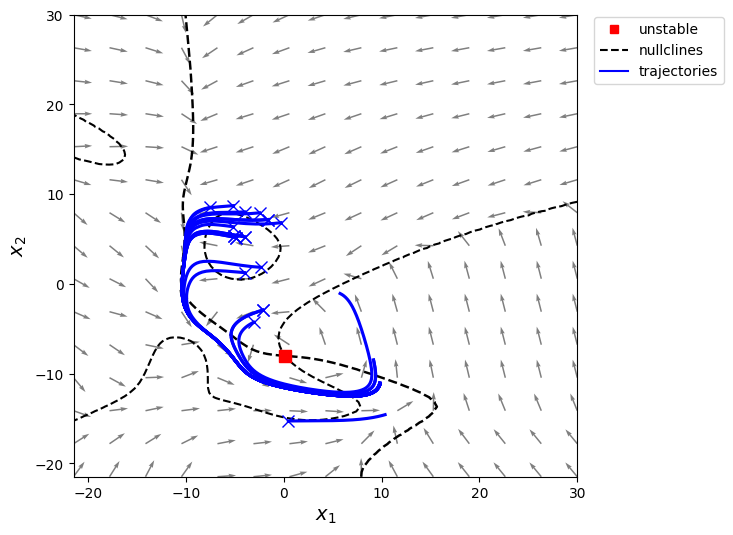

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = [(X_t_high[i,0,0],X_t_high[i,0,1]) for i in inits_idx]
timeVec = np.linspace(0, 750, 1000)
x1vec = np.linspace(xlim[0]-1.5,xlim[1],100)
x2vec = np.linspace(ylim[0]-1.5,ylim[1],100)
fig = pplane.plot_portrait(f1,f2,x1vec,x2vec,tVec=timeVec,ICs=inits,N1_coarse=20)

Text(0.5, 0, '$t$ (minutes)')

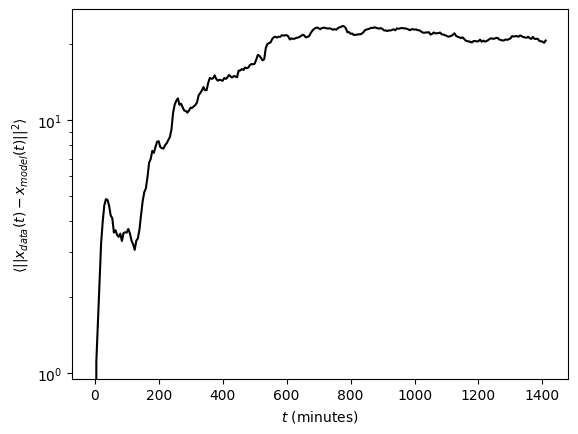

In [ ]:
# compare actual trajectories to predicted trajectories
def mySystem(t,x):
    return np.array([f1(x[0],x[1]),f2(x[0],x[1])])
        
traj_model = np.array([sc.integrate.solve_ivp(mySystem,y0=init,t_span=(0,t_change),t_eval=np.arange(t_change)).y.T for init in inits])
traj_true = np.array([X_t_high[i,:,:2] for i in inits_idx])

traj_err = [np.linalg.norm(traj_model[i]-traj_true[i],axis=1) for i in range(len(inits))]

plt.semilogy(5*np.arange(t_change),np.mean(traj_err,axis=0),'k-')
plt.ylabel('$\\langle ||x_{data}(t)-x_{model}(t)||^2 \\rangle$')
plt.xlabel('$t$ (minutes)')

##### Model training: low flow

In [ ]:
svfc_model_low = svfc.SparseVFC(kernel='rbf',beta=0.05,M=250,seed=35).fit(X_train_low,Y_train_low)

inlier_idx = svfc_model_low.inliers_

R2_rbf_test = svfc_model_low.score(X_test_low,Y_test_low)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(inlier_idx) == 0:
    stdev_rbf_inliers = np.nan
else:
    stdev_rbf_inliers = np.sqrt((1/len(inlier_idx))*np.sum(np.linalg.norm(svfc_model_low.predict(X_train_low[inlier_idx,:])-Y_train_low[inlier_idx,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(inlier_idx))
print('Coefficient of determination (R^2) of RBF kernel model on test set: %f' %R2_rbf_test)
print('Standard deviation of RBF kernel model on training set inliers: %f' %stdev_rbf_inliers)

Number of inlier points identified by SparseVFC algorithm:  12256
Coefficient of determination (R^2) of RBF kernel model on test set: -0.005111
Standard deviation of RBF kernel model on training set inliers: 0.334448


In [ ]:
# data already along PC components
# so projection matrix to top 2 pc components is just the (num_modes_95)x2 matrix [e_0 e_1]
W = np.column_stack((np.eye(num_modes_95)[0,:],np.eye(num_modes_95)[1,:]))
svfc_model_low.project2D(W) # projects coefficent vectors into 2D (each coefficient vector is a row vector)
X_low_pca = X_low@W

In [ ]:
xlim = [-20,30]
ylim = [-20,30]
N_mesh = 40
U1,U2 = np.meshgrid(np.linspace(xlim[0],xlim[1],N_mesh),np.linspace(ylim[0],ylim[1],N_mesh))
V = svfc_model_low.predict_2D_mesh([U1,U2])

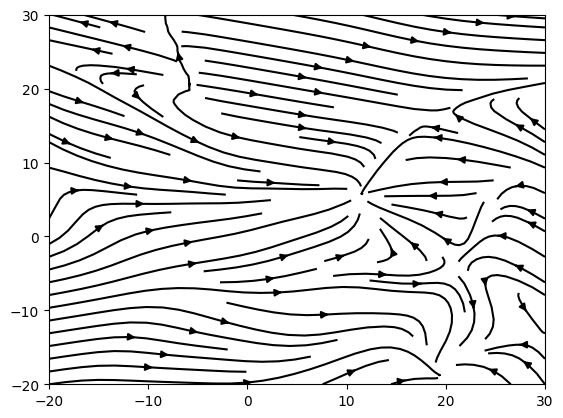

In [ ]:
fig = plt.streamplot(U1,U2,V[:,:,0],V[:,:,1],color='k')

In [ ]:
def f(X1,X2,svfc_2D):
    if not hasattr(svfc_2D,'proj_'): 
        svfc_2D.project2D(np.eye(2))
    if X1.ndim == 2:
        return np.swapaxes(svfc_2D.predict_2D_mesh([X1,X2]),0,1).T
    else:
        return svfc_2D.predict_2D(np.array([X1,X2]))[0]

def f1(x1,x2):
    return f(x1,x2,svfc_model_low)[0]

def f2(x1,x2):
    return f(x1,x2,svfc_model_low)[1]

Fixed points:
  • Unstable node at x = (-5.663,20.047)
  • Saddle point at x = (17.801,15.208)
  • Unstable spiral at x = (29.809,-8.602)
  • Stable node at x = (11.480,5.716)
  • Stable spiral at x = (19.349,-18.821)
  • Saddle point at x = (20.716,-3.489)
  • Saddle point at x = (29.554,-13.428)


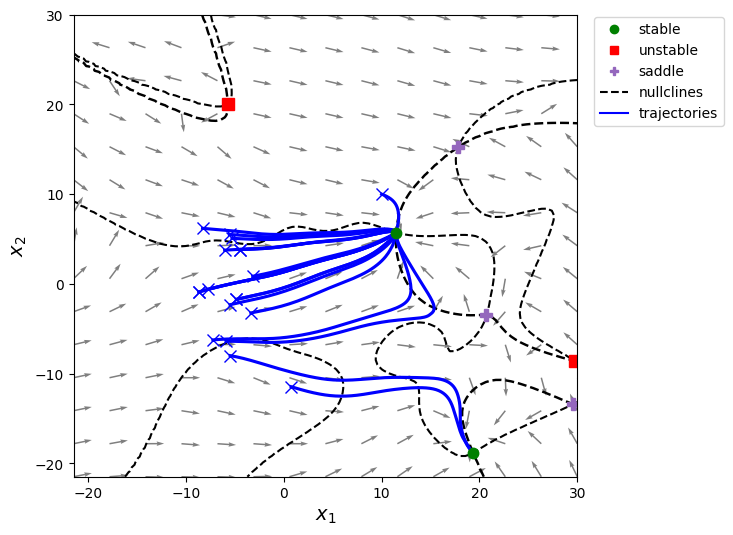

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = [(X_t_low[i,5,0],X_t_low[i,5,1]) for i in inits_idx]
timeVec = np.linspace(0, 750, 1000)
x1vec = np.linspace(xlim[0]-1.5,xlim[1],100)
x2vec = np.linspace(ylim[0]-1.5,ylim[1],100)
fig = pplane.plot_portrait(f1,f2,x1vec,x2vec,tVec=timeVec,ICs=inits+[(10,10)])

Text(0.5, 0, '$t$ (minutes)')

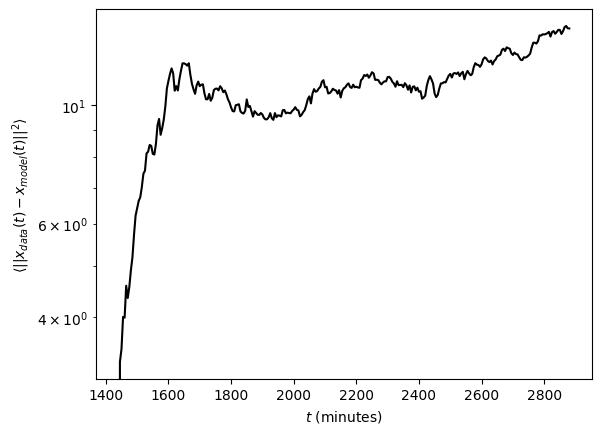

In [ ]:
# compare actual trajectories to predicted trajectories
def mySystem(t,x):
    return np.array([f1(x[0],x[1]),f2(x[0],x[1])])
        
traj_model = np.array([sc.integrate.solve_ivp(mySystem,y0=init,t_span=(0,(num_t-t_change-5)),t_eval=np.arange(num_t-t_change-5)).y.T for init in inits])
traj_true = np.array([X_t_low[i,5:,:2] for i in inits_idx])

traj_err = [np.linalg.norm(traj_model[i]-traj_true[i],axis=1) for i in range(len(inits))]

plt.semilogy(5*np.arange(t_change+5,num_t),np.mean(traj_err,axis=0),'k-')
plt.ylabel('$\\langle ||x_{data}(t)-x_{model}(t)||^2 \\rangle$')
plt.xlabel('$t$ (minutes)')

##### Model training: no high/low split

In [ ]:
dt = 5 # time units = (5 minutes)/dt 

# get velocity vectors for each trajectory, again putting np.nan where data are missing and/or dx/dt cannot be estimated
dX_all = np.gradient(X_t,dt,axis=1)

# now, build arrays of X (points along single cell trajectories) and corresponding Y = dX/dt|_X: dim is sum(num_non_nan_timepoints per trajectory) x num_feats
X_all = np.concatenate(X_t,axis=0)
Y_all = np.concatenate(dX_all,axis=0)

In [ ]:
# build training and test sets
N_tot = X_all.shape[0]
N_train = int(0.8*N_tot) # 80% of data for training
N_test = N_tot-N_train

X_train_all, X_test_all, Y_train_all, Y_test_all = train_test_split(X_all, Y_all, test_size=N_test, random_state=345)

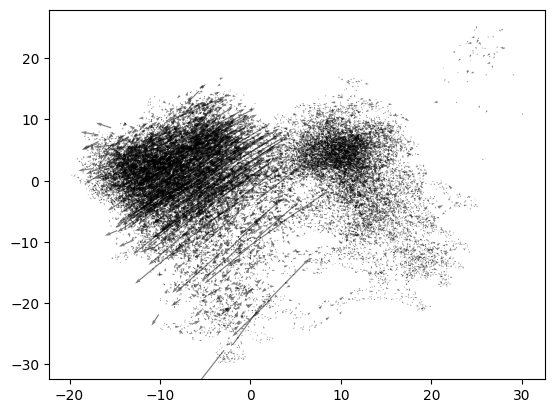

In [ ]:
plt.quiver(X_all[:,0],X_all[:,1],Y_all[:,0],Y_all[:,1],color='k',alpha=0.5,scale=30) # plot velocity vectors in top two PCA space

In [ ]:
svfc_model_all = svfc.SparseVFC(kernel='rbf',beta=0.05,M=250,seed=45).fit(X_train_all,Y_train_all)

inlier_idx = svfc_model_all.inliers_

R2_rbf_test = svfc_model_low.score(X_test_all,Y_test_all)

# paper suggests using metric standard deviation of inlier set instead of MSE
if len(inlier_idx) == 0:
    stdev_rbf_inliers = np.nan
else:
    stdev_rbf_inliers = np.sqrt((1/len(inlier_idx))*np.sum(np.linalg.norm(svfc_model_all.predict(X_train_all[inlier_idx,:])-Y_train_all[inlier_idx,:],axis=1)**2))

print("Number of inlier points identified by SparseVFC algorithm: ",len(inlier_idx))
print('Coefficient of determination (R^2) of RBF kernel model on test set: %f' %R2_rbf_test)
print('Standard deviation of RBF kernel model on training set inliers: %f' %stdev_rbf_inliers)

Number of inlier points identified by SparseVFC algorithm:  23947
Coefficient of determination (R^2) of RBF kernel model on test set: -0.004557
Standard deviation of RBF kernel model on training set inliers: 0.237578


In [ ]:
# data already along PC components
# so projection matrix to top 2 pc components is just the (num_modes_95)x2 matrix [e_0 e_1]
W = np.column_stack((np.eye(num_modes_95)[0,:],np.eye(num_modes_95)[1,:]))
svfc_model_all.project2D(W) # projects coefficent vectors into 2D (each coefficient vector is a row vector)

In [ ]:
xlim = [-20,30]
ylim = [-20,30]
N_mesh = 40
U1,U2 = np.meshgrid(np.linspace(xlim[0],xlim[1],N_mesh),np.linspace(ylim[0],ylim[1],N_mesh))
V = svfc_model_all.predict_2D_mesh([U1,U2])

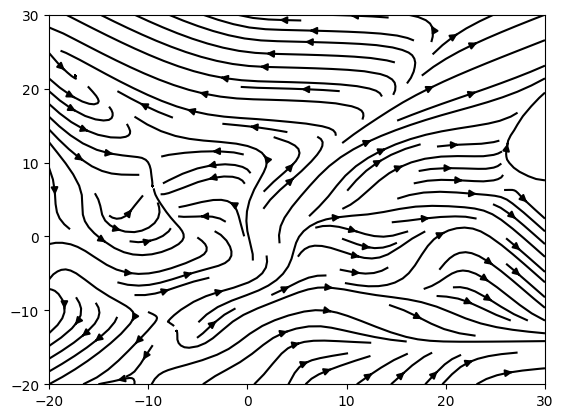

In [ ]:
plt.streamplot(U1,U2,V[:,:,0],V[:,:,1],color='k')

In [ ]:
def f(X1,X2,svfc_2D):
    if not hasattr(svfc_2D,'proj_'): 
        svfc_2D.project2D(np.eye(2))
    if X1.ndim == 2:
        return np.swapaxes(svfc_2D.predict_2D_mesh([X1,X2]),0,1).T
    else:
        return svfc_2D.predict_2D(np.array([X1,X2]))[0]

def f1(x1,x2):
    return f(x1,x2,svfc_model_all)[0]

def f2(x1,x2):
    return f(x1,x2,svfc_model_all)[1]

Fixed points:
  • Unstable node at x = (-21.582,-9.190)
  • Indeterminate stability at x = (-23.674,-25.071)
  • Stable spiral at x = (-17.297,21.441)
  • Saddle point at x = (-10.336,-18.566)
  • Saddle point at x = (-8.276,-11.257)
  • Stable node at x = (-9.505,6.862)
  • Saddle point at x = (-10.148,11.545)
  • Unstable node at x = (-6.985,-12.860)
  • Saddle point at x = (26.755,6.185)


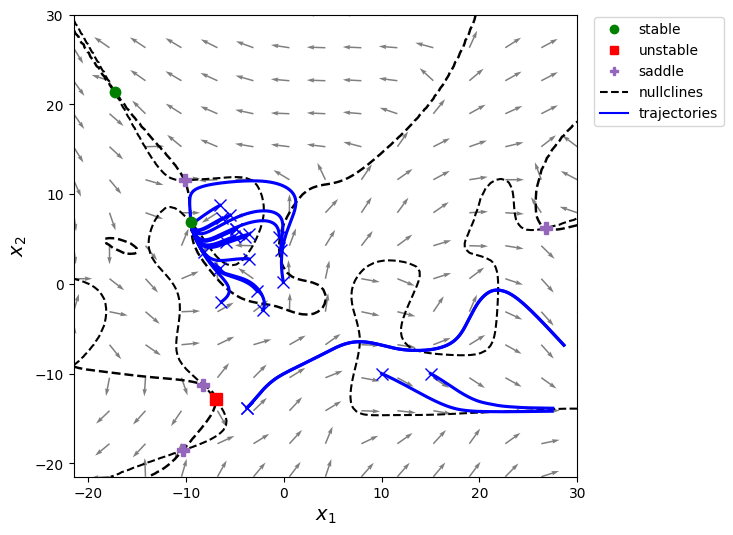

In [ ]:
inits_idx = np.random.choice(np.arange(num_loc),size=20)
inits = [(X_t[i,0,0],X_t[i,0,1]) for i in inits_idx]
timeVec = np.linspace(0, 750, 1000)
x1vec = np.linspace(xlim[0]-1.5,xlim[1],100)
x2vec = np.linspace(ylim[0]-1.5,ylim[1],100)
fig = pplane.plot_portrait(f1,f2,x1vec,x2vec,tVec=timeVec,ICs=inits+[(10,-10),(15,-10)])

Text(0.5, 0, '$t$ (minutes)')

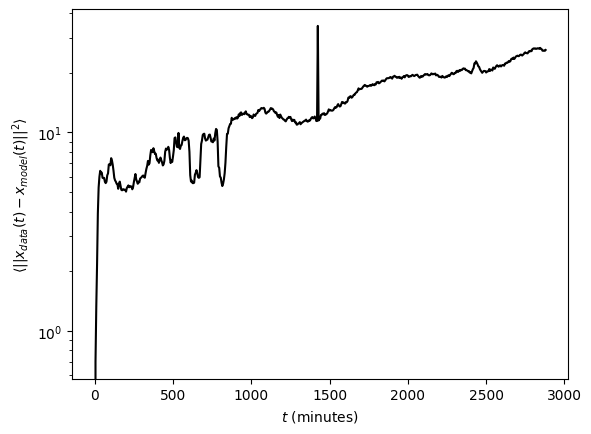

In [ ]:
# compare actual trajectories to predicted trajectories
def mySystem(t,x):
    return np.array([f1(x[0],x[1]),f2(x[0],x[1])])
        
traj_model = np.array([sc.integrate.solve_ivp(mySystem,y0=init,t_span=(0,num_t),t_eval=np.arange(num_t)).y.T for init in inits])
traj_true = np.array([X_t[i,:,:2] for i in inits_idx])

traj_err = [np.linalg.norm(traj_model[i]-traj_true[i],axis=1) for i in range(len(inits))]

plt.semilogy(5*np.arange(num_t),np.mean(traj_err,axis=0),'k-')
plt.ylabel('$\\langle ||x_{data}(t)-x_{model}(t)||^2 \\rangle$')
plt.xlabel('$t$ (minutes)')